In [1]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle
from scipy.stats import percentileofscore
from statsmodels.stats.contingency_tables import mcnemar

from PIL import Image

import cartopy.crs as ccrs
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['font.sans-serif']=['Verdana']

params = {"ytick.color": "k",
          "xtick.color": "k",
          "axes.labelcolor": "k",
          "axes.edgecolor": "k"}
plt.rcParams.update(params)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [3]:
ssplist = ["370"]

ssplistplot = ["hist","370"] # thank god i haven't flipflopped on ssp labeling! that would be so annoying

# set user parameters

experiment_era = [1970,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1970,2025]
baselineera_obs = [1950,1980]

inputlength = 10
outputavgtime = 5
# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

ntrain = 25
nval = 13
test = np.arange(38,50)

n_best = 3

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

lonmesh,latmesh = np.meshgrid(lonvec+5,latvec+5)

device = 'mps'


data/MPI_annualmean_370_tos_1900-2100.pkl


In [4]:

imp.reload(DataHolder)
AllObs = DataHolder.ERA5InputOutput(params)
lenobs = experiment_era_obs[1]-experiment_era_obs[0]-outputavgtime-inputlength+1

In [56]:
def input_times_gradient(model, sst_map, gmta_scalar, target_class_idx=None):
    """
    sst_map: Tensor of shape (1, C, H, W)
    gmta_scalar: Tensor of shape (1, 1) or (1,)
    """
    model.eval()
    
    # Enable gradient tracking on input tensors
    sst_map = sst_map.clone().detach().requires_grad_(True)
    gmta_scalar = gmta_scalar.clone().detach().requires_grad_(True)
    
    # Forward pass
    output = get_logits(model, sst_map, gmta_scalar)
    
    # Handle single binary output vs multi-class logits
    if output.shape[-1] == 1:
        target_logit = output[0, 0]
    else:
        target_logit = output[0, target_class_idx]
        
    # Zero existing gradients and compute gradients w.r.t. inputs
    model.zero_grad()
    target_logit.backward()
    
    # Compute Input * Gradient
    sst_attr = (sst_map * sst_map.grad).squeeze().detach().cpu().numpy()
    gmta_attr = (gmta_scalar * gmta_scalar.grad).detach().cpu().numpy()
    
    return sst_attr, gmta_attr

def get_logits(model, sst_map, gmta_scalar):
    # 1. Forward through Conv layers
    x = sst_map
    for layer in model.conv_layers:
        x = layer(x)
        
    # 2. Flatten
    x = model.flatten(x)
    
    # 3. Concatenate global mean temperature anomaly
    x = torch.cat((x, gmta_scalar), dim=1)
    
    # 4. Forward through hidden dense layers
    for layer in model.linear_layers:
        x = layer(x)
        
    # 5. Output layer (Pre-softmax logits)
    logits = model.output_layer(x)
    
    return logits    

In [117]:
latsel = 40
lonsel = 0

metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed*.json"
filelist = glob.glob(metricsout)

bestseeds = helpers.get_best_files(filelist,n_best)
obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_histrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)
# obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)

obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)
obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)

obspredall = np.empty((3,len(obsinputgmt)))

_, _, alltest = AllData.trainvaltest_histrecordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

MPIinputtest, MPIinputtestGMT, MPIoutputtest = DataHolder.tensortime_onehot_withrecordmax(alltest,nclasses=2)

MPIpredall = np.empty((3,12,47))

XAI_obs_SST = np.empty(obsinput_t.shape)
XAI_obs_GMT = np.empty(obsinputvectors_t.shape)

XAI_MPI_SST = []
XAI_MPI_GMT = []

device = 'cpu'

for iseed,seed in enumerate(bestseeds):
    # load the model

    loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed_"+str(seed)+".pt"
    cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
    cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
    cnn.to(device)
    cnn.eval()

    with torch.no_grad():
        obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()

    for i in range(len(obspred)):
        XAI_obs_SST[i],XAI_obs_GMT[i] = input_times_gradient(cnn,obsinput_t[[i]],obsinputvectors_t[[i]],target_class_idx=1)

    for imem in range(12):

        inds = np.arange(35*(imem),35*(imem+1))
        inds2 = 300+np.arange((imem)*79,(imem)*79+12)

        inds = np.concatenate((inds,inds2))

        MPISSTsub = MPIinputtest[inds]
        # inputobssub = obsinputvectors_t[10:47]
        inputobssub = obsinputvectors_t

        with torch.no_grad():
            MPIpred = cnn(MPISSTsub.to(device), inputobssub.to(device)).cpu().numpy()

        MPIpredall[iseed,imem] = MPIpred[:,1]

        XAI_MPI_SST_loop = np.empty(MPISSTsub.shape)
        XAI_MPI_GMT_loop = np.empty(inputobssub.shape)

        for i in range(len(obspred)):
            XAI_MPI_SST_loop[i],XAI_MPI_GMT_loop[i] = input_times_gradient(cnn,MPISSTsub[[i]],obsinputvectors_t[[i]],target_class_idx=1)

        XAI_MPI_SST.append(XAI_MPI_SST_loop)
        XAI_MPI_GMT.append(XAI_MPI_GMT_loop)

    obspredall[iseed] = obspred[:,1]

obspredavg = np.mean(obspredall,axis=0)
obspredclass = np.round(obspredavg)
MPIpredavg = np.mean(MPIpredall,axis=0)


baseline for temp records is 0 50 (not used)
indices of future period are 104 -4
working on 370


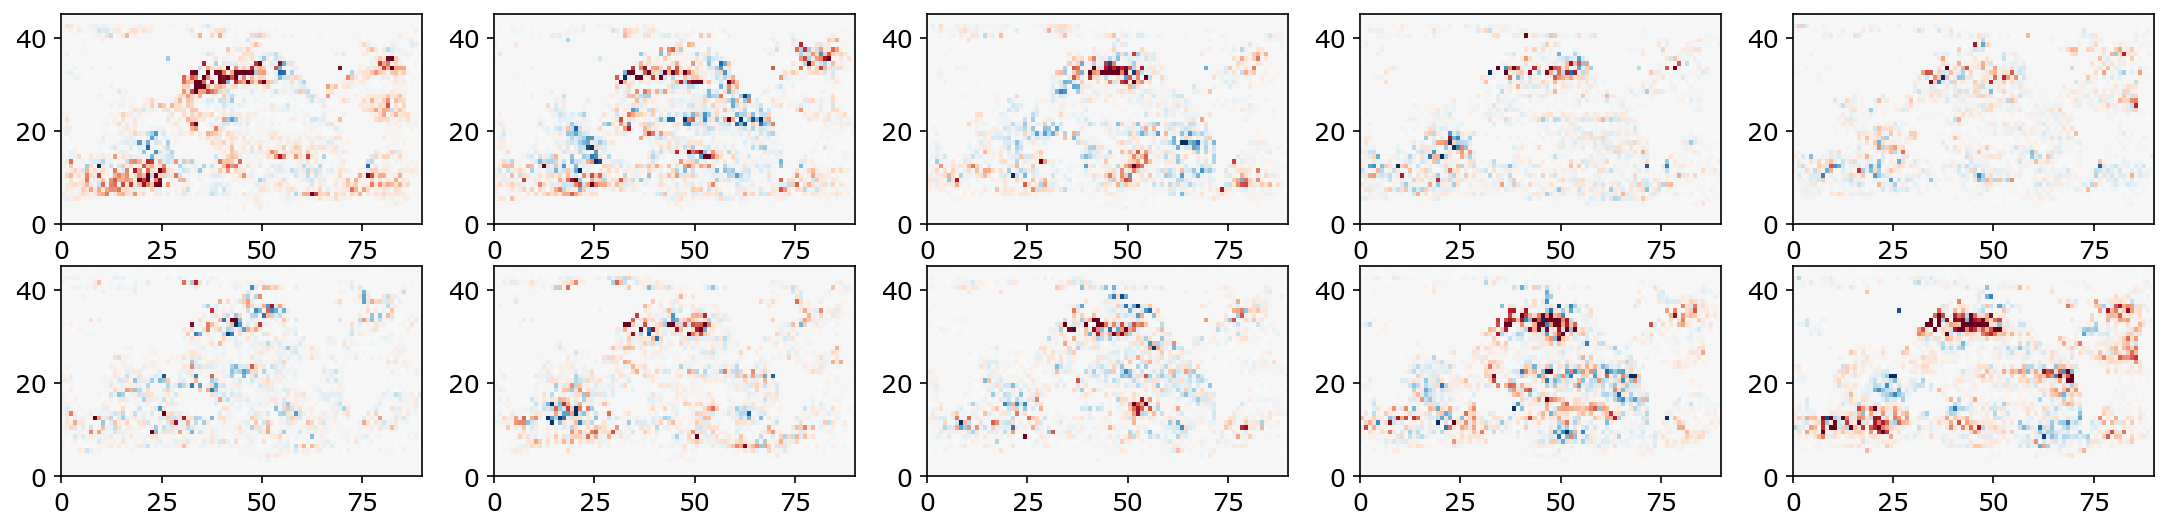

In [122]:
plt.figure(figsize=(18,4))

for iplot in range(10):
    plt.subplot(2,5,iplot+1)
    plt.pcolormesh(XAI_obs_SST[-3,iplot],vmin=-0.001,vmax=0.001,cmap="RdBu_r")

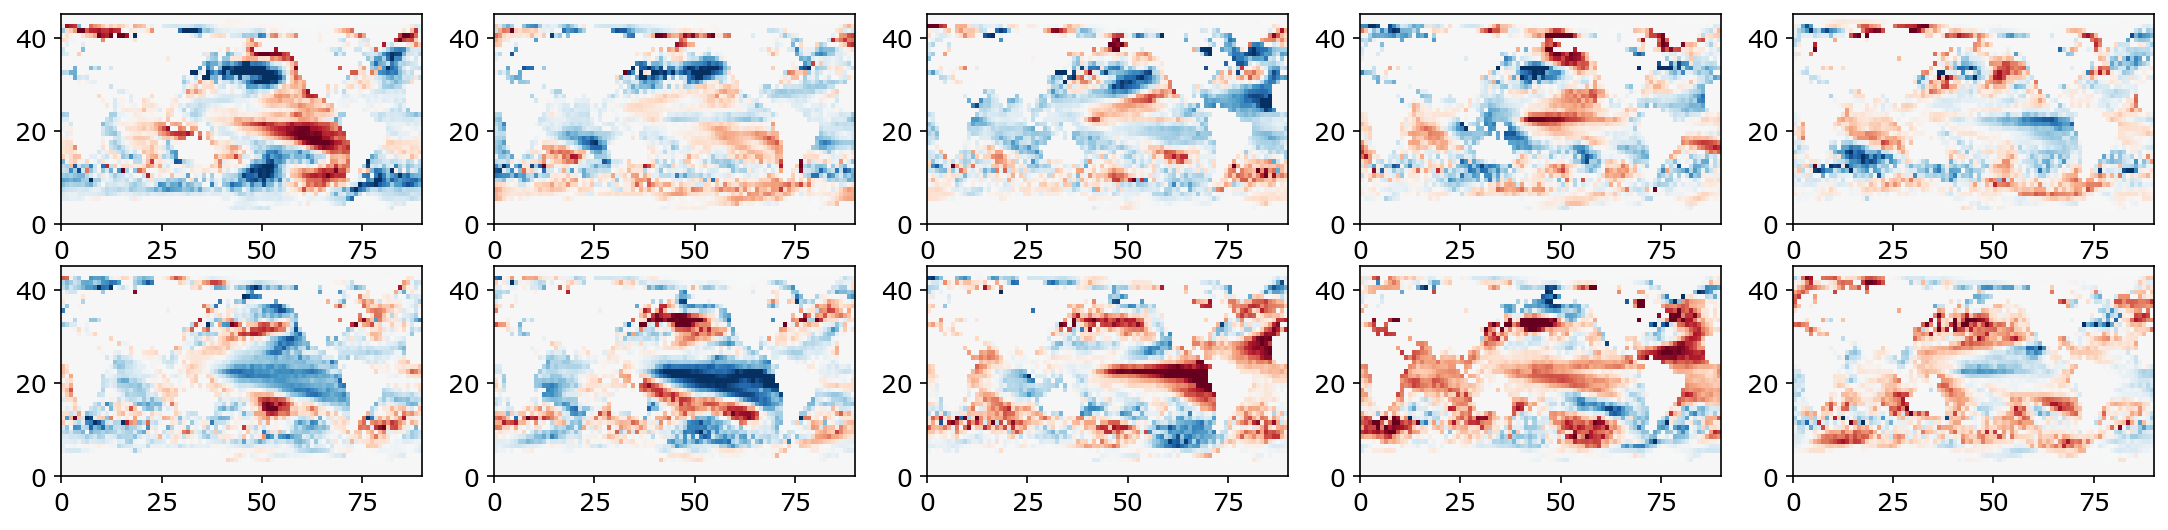

In [119]:
plt.figure(figsize=(18,4))

for iplot in range(10):
    plt.subplot(2,5,iplot+1)
    plt.pcolormesh(obsinput_t[-1,iplot],vmin=-1,vmax=1,cmap="RdBu_r")

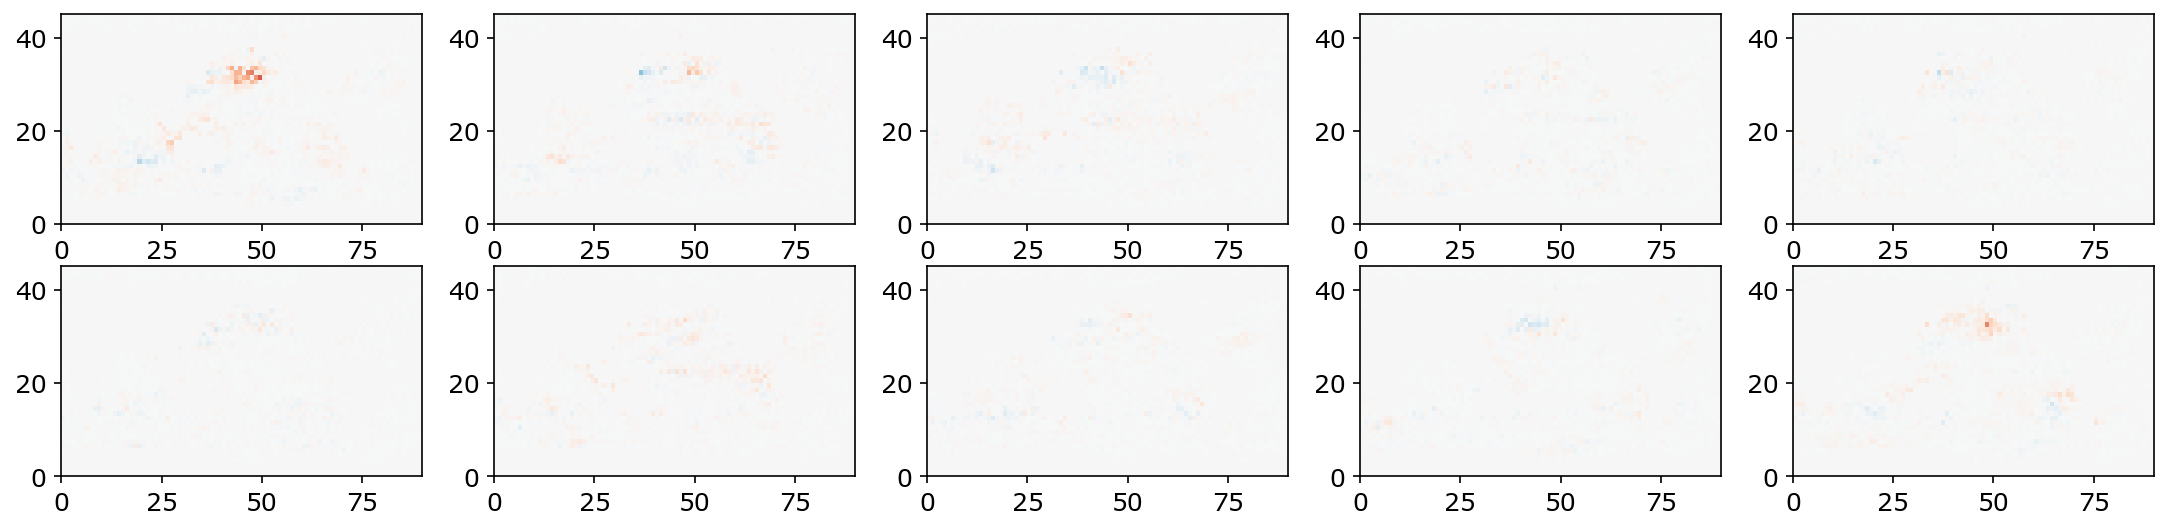

In [120]:
plt.figure(figsize=(18,4))

for iplot in range(10):
    plt.subplot(2,5,iplot+1)

    plt.pcolormesh(XAI_MPI_SST[-7][-1,iplot],vmin=-0.01,vmax=0.01,cmap="RdBu_r")

In [134]:
latsel = 40
lonsel = 240

metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed*.json"
filelist = glob.glob(metricsout)

bestseeds = helpers.get_best_files(filelist,n_best)
obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_histrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)
# obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)

obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
obsinputgmt_t = 0*torch.tensor(obsinputgmt,dtype=torch.float32)+0.1
obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)
obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)

obspredall = np.empty((3,len(obsinputgmt)))

_, _, alltest = AllData.trainvaltest_histrecordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

MPIinputtest, MPIinputtestGMT, MPIoutputtest = DataHolder.tensortime_onehot_withrecordmax(alltest,nclasses=2)

MPIpredall = np.empty((3,12,47))

XAI_obs_SST = np.empty(obsinput_t.shape)
XAI_obs_GMT = np.empty(obsinputvectors_t.shape)

XAI_MPI_SST = []
XAI_MPI_GMT = []

device = 'cpu'

for iseed,seed in enumerate(bestseeds):
    # load the model

    loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed_"+str(seed)+".pt"
    cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
    cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
    cnn.to(device)
    cnn.eval()

    with torch.no_grad():
        obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()

    for i in range(len(obspred)):
        XAI_obs_SST[i],XAI_obs_GMT[i] = input_times_gradient(cnn,obsinput_t[[i]],obsinputvectors_t[[i]],target_class_idx=1)

    for imem in range(12):

        inds = np.arange(35*(imem),35*(imem+1))
        inds2 = 300+np.arange((imem)*79,(imem)*79+12)

        inds = np.concatenate((inds,inds2))

        MPISSTsub = MPIinputtest[inds]
        # inputobssub = obsinputvectors_t[10:47]
        inputobssub = obsinputvectors_t

        with torch.no_grad():
            MPIpred = cnn(MPISSTsub.to(device), inputobssub.to(device)).cpu().numpy()

        MPIpredall[iseed,imem] = MPIpred[:,1]

        XAI_MPI_SST_loop = np.empty(MPISSTsub.shape)
        XAI_MPI_GMT_loop = np.empty(inputobssub.shape)

        for i in range(len(obspred)):
            XAI_MPI_SST_loop[i],XAI_MPI_GMT_loop[i] = input_times_gradient(cnn,MPISSTsub[[i]],obsinputvectors_t[[i]],target_class_idx=1)

        XAI_MPI_SST.append(XAI_MPI_SST_loop)
        XAI_MPI_GMT.append(XAI_MPI_GMT_loop)

    obspredall[iseed] = obspred[:,1]

obspredavg = np.mean(obspredall,axis=0)
obspredclass = np.round(obspredavg)
MPIpredavg = np.mean(MPIpredall,axis=0)


baseline for temp records is 0 50 (not used)
indices of future period are 104 -4
working on 370


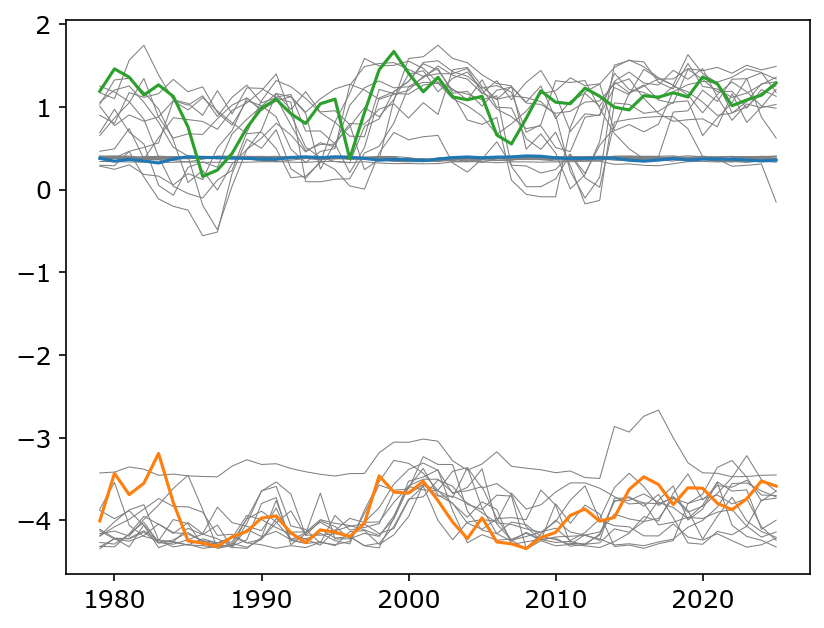

In [135]:
yearvec = np.arange(1979,2026)
for imem in range(12):
    plt.plot(yearvec,XAI_MPI_GMT[-1*imem][:,0],color='grey',linewidth=0.5)
    plt.plot(yearvec,XAI_MPI_GMT[-1*imem][:,1],color='grey',linewidth=0.5)
    plt.plot(yearvec,np.sum(XAI_MPI_SST[-1*imem],axis=(1,2,3)),linewidth=0.5,color='grey')

plt.plot(yearvec,XAI_obs_GMT[:,0])
plt.plot(yearvec,XAI_obs_GMT[:,1])

plt.plot(yearvec,np.sum(XAI_obs_SST,axis=(1,2,3)))


In [43]:
a

tensor([[ 3.0272, -2.9426],
        [ 2.6409, -2.5937],
        [ 2.5820, -2.5040],
        [ 2.7458, -2.7335],
        [ 1.8408, -1.8597],
        [ 2.5264, -2.4812],
        [ 2.7390, -2.6087],
        [ 3.4188, -3.2339],
        [ 2.9859, -2.8805],
        [ 2.2660, -2.1071],
        [ 2.4874, -2.3119],
        [ 1.7779, -1.5878],
        [ 1.4677, -1.3310],
        [ 1.7864, -1.6584],
        [ 2.2176, -2.1417],
        [ 2.2263, -2.1159],
        [ 2.2548, -2.1068],
        [ 2.7347, -2.5543],
        [ 1.9973, -1.9505],
        [ 0.4511, -0.4172],
        [ 0.6227, -0.5418],
        [ 0.6956, -0.5951],
        [ 0.2068, -0.0908],
        [ 0.2110, -0.1076],
        [ 0.2316, -0.1106],
        [ 0.3301, -0.2251],
        [ 0.3346, -0.2130],
        [ 1.1160, -0.9618],
        [ 1.3468, -1.2058],
        [ 1.1122, -1.0007],
        [ 0.7454, -0.6578],
        [ 0.6158, -0.5036],
        [ 0.8161, -0.7180],
        [ 0.8981, -0.8003],
        [ 0.8790, -0.7512],
        [ 0.6467, -0

In [58]:
a,b=input_times_gradient(cnn,obsinput_t[[i]],obsinputvectors_t[[i]],target_class_idx=1)

In [59]:
a

array([[[-0.00000000e+00,  0.00000000e+00, -0.00000000e+00, ...,
         -0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -0.00000000e+00, -0.00000000e+00,  0.00000000e+00],
        [-0.00000000e+00, -0.00000000e+00,  0.00000000e+00, ...,
         -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
        ...,
        [-4.78473021e-06,  5.72882709e-05,  1.03075494e-04, ...,
          2.18411156e-08, -2.85896751e-09,  8.05949529e-10],
        [ 4.00424138e-09, -9.15116982e-10,  7.26603044e-09, ...,
          1.23883709e-10, -4.18414886e-11,  1.52307125e-11],
        [-3.04379189e-09,  2.62326871e-09,  3.30911321e-09, ...,
         -1.95812672e-11,  4.75261740e-11, -9.14446036e-12]],

       [[-0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00, -0.00000000e+00,  0.00000000e+00],
        [-0.00000000e+00,  0.00000000e+00, -0.00000000e+00, ...,
         -0.00000000e+00, -0.00000000e

In [40]:
model2(obsinput_t,obsinputvectors_t)

TypeError: forward() takes 2 positional arguments but 3 were given